# Hotel Reservation Cancellation - Random Forest (Beginner Workflow)


In [182]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


## 1) Load Data


In [183]:
DATA_PATH = "hotel.csv"
data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
data.head()


Shape: (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 2) Basic Checks


In [184]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [185]:
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.0,NaN,NaN,NaN,1.844962,0.518715,0.0,2.0,2.0,2.0,4.0
no_of_children,36275.0,NaN,NaN,NaN,0.105279,0.402648,0.0,0.0,0.0,0.0,10.0
no_of_weekend_nights,36275.0,NaN,NaN,NaN,0.810724,0.870644,0.0,0.0,1.0,2.0,7.0
no_of_week_nights,36275.0,NaN,NaN,NaN,2.2043,1.410905,0.0,1.0,2.0,3.0,17.0
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.0,NaN,NaN,NaN,0.030986,0.173281,0.0,0.0,0.0,0.0,1.0
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.0,NaN,NaN,NaN,85.232557,85.930817,0.0,17.0,57.0,126.0,443.0
arrival_year,36275.0,NaN,NaN,NaN,2017.820427,0.383836,2017.0,2018.0,2018.0,2018.0,2018.0


## 3) Quick Category Checks


In [186]:
for col in [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
    "required_car_parking_space",
    "no_of_special_requests",
    "no_of_children",
    "booking_status",
]:
    print(f"\n{col}")
    print(data[col].value_counts().head(10))



type_of_meal_plan
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64

room_type_reserved
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

market_segment_type
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

required_car_parking_space
required_car_parking_space
0    35151
1     1124
Name: count, dtype: int64

no_of_special_requests
no_of_special_requests
0    19777
1    11373
2     4364
3      675
4       78
5        8
Name: count, dtype: int64

no_of_children
no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64

booking_status
booking_status
Not_Canceled    24390
Canceled        11885
Name: cou

## 4) Data Cleanup


In [187]:
# Small cleanup: remove extreme children outliers (rare and unrealistic)
data = data[data["no_of_children"] <= 3].copy()
data.reset_index(drop=True, inplace=True)

print("Shape after cleanup:", data.shape)


Shape after cleanup: (36272, 19)


## 5) Feature Engineering


In [188]:
# Keep only derived features for guest count and stay length
data["total_guests"] = data["no_of_adults"] + data["no_of_children"]
data["total_stays"] = data["no_of_week_nights"] + data["no_of_weekend_nights"]

# Remove zero-night bookings if any
data = data[data["total_stays"] > 0].copy()
data.reset_index(drop=True, inplace=True)

print(data[["total_guests", "total_stays"]].describe())


       total_guests   total_stays
count  36194.000000  36194.000000
mean       1.949992      3.021440
std        0.644963      1.782385
min        1.000000      1.000000
25%        2.000000      2.000000
50%        2.000000      3.000000
75%        2.000000      4.000000
max        5.000000     24.000000


## 6) Convert Price EUR -> NPR (Live Rate with Fallback)


In [189]:
EUR_TO_NPR = 171.0

print("EUR_TO_NPR used:", EUR_TO_NPR)

# Keep original and convert for modeling aligned with local currency app pricing
data["avg_price_per_room_eur"] = data["avg_price_per_room"]
data["avg_price_per_room"] = (data["avg_price_per_room_eur"] * EUR_TO_NPR).round(2)

data[["avg_price_per_room_eur", "avg_price_per_room"]].head()


EUR_TO_NPR used: 171.0


,avg_price_per_room_eur,avg_price_per_room
0,65.00,11115.00
1,106.68,18242.28
2,60.00,10260.00
3,100.00,17100.00
4,94.50,16159.50


## 7) Encode Target and Categorical Features


In [190]:
# Target encoding
data["cancellation"] = data["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

encoders = {}

segment_encoder = LabelEncoder()
data["market_segment_type_encoded"] = segment_encoder.fit_transform(data["market_segment_type"].astype(str))
encoders["market_segment_type"] = segment_encoder

print("Segment classes:", list(segment_encoder.classes_))
print("Cancellation ratio:")
print(data["cancellation"].value_counts(normalize=True))


Segment classes: ['Aviation', 'Complementary', 'Corporate', 'Offline', 'Online']
Cancellation ratio:
cancellation
0    0.671714
1    0.328286
Name: proportion, dtype: float64


## 8) EDA Visuals


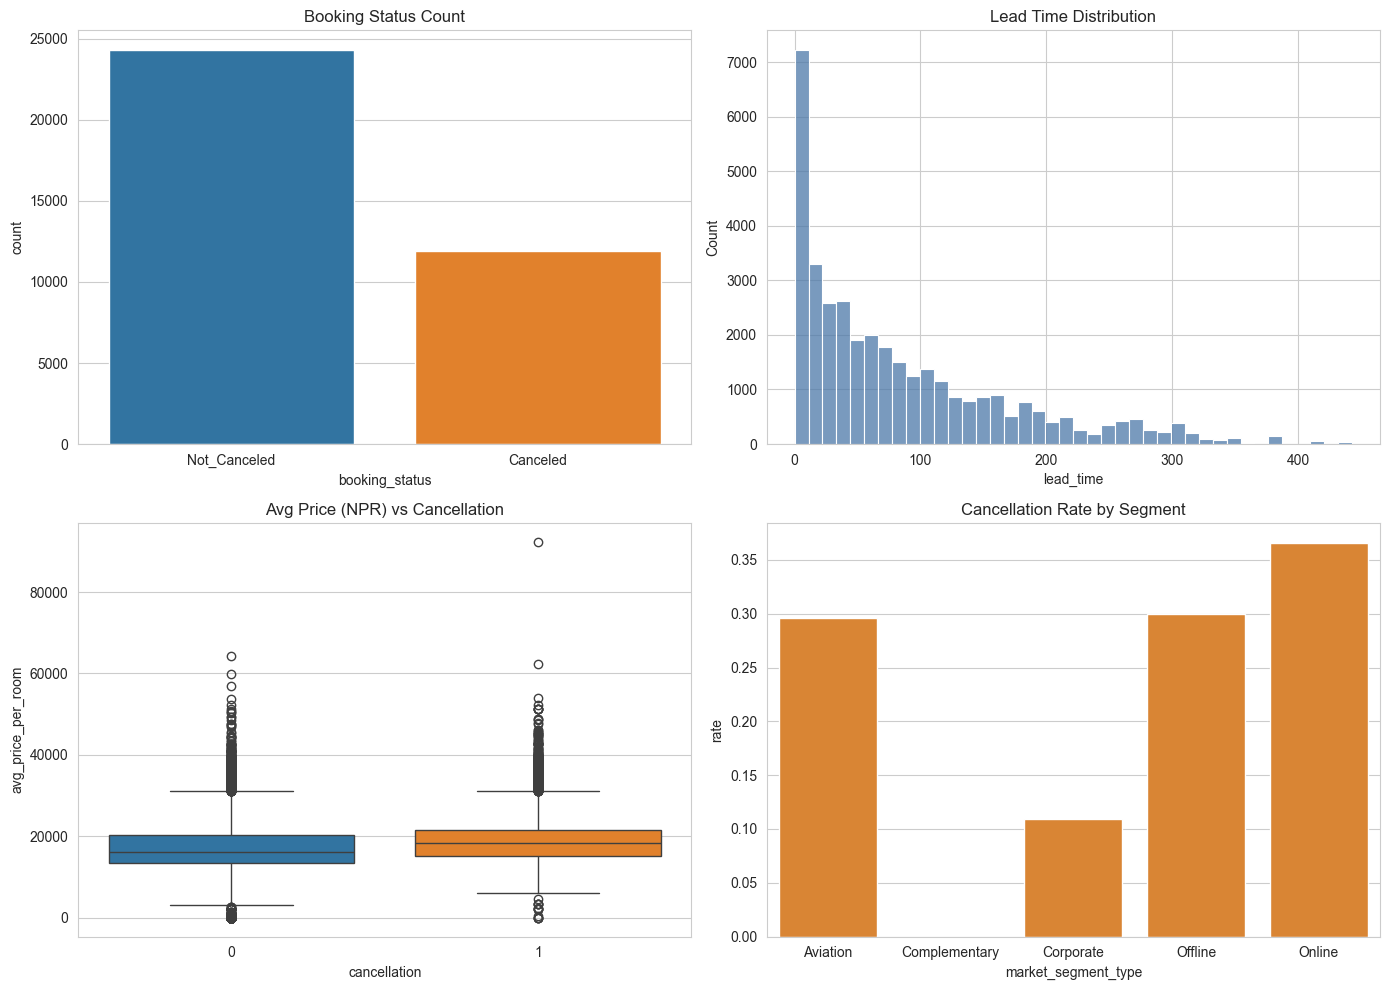

In [191]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=data, x="booking_status", hue="booking_status", legend=False, ax=ax[0, 0])
ax[0, 0].set_title("Booking Status Count")

sns.histplot(data=data, x="lead_time", bins=40, color="#4C78A8", ax=ax[0, 1])
ax[0, 1].set_title("Lead Time Distribution")

sns.boxplot(data=data, x="cancellation", y="avg_price_per_room", hue="cancellation", legend=False, ax=ax[1, 0])
ax[1, 0].set_title("Avg Price (NPR) vs Cancellation")

segment_rate = data.groupby("market_segment_type", as_index=False)["cancellation"].mean()
sns.barplot(data=segment_rate, x="market_segment_type", y="cancellation", color="#F58518", ax=ax[1, 1])
ax[1, 1].set_title("Cancellation Rate by Segment")
ax[1, 1].set_ylabel("rate")

plt.tight_layout()
plt.show()


## 9) Correlation Heatmap (Numeric Features)


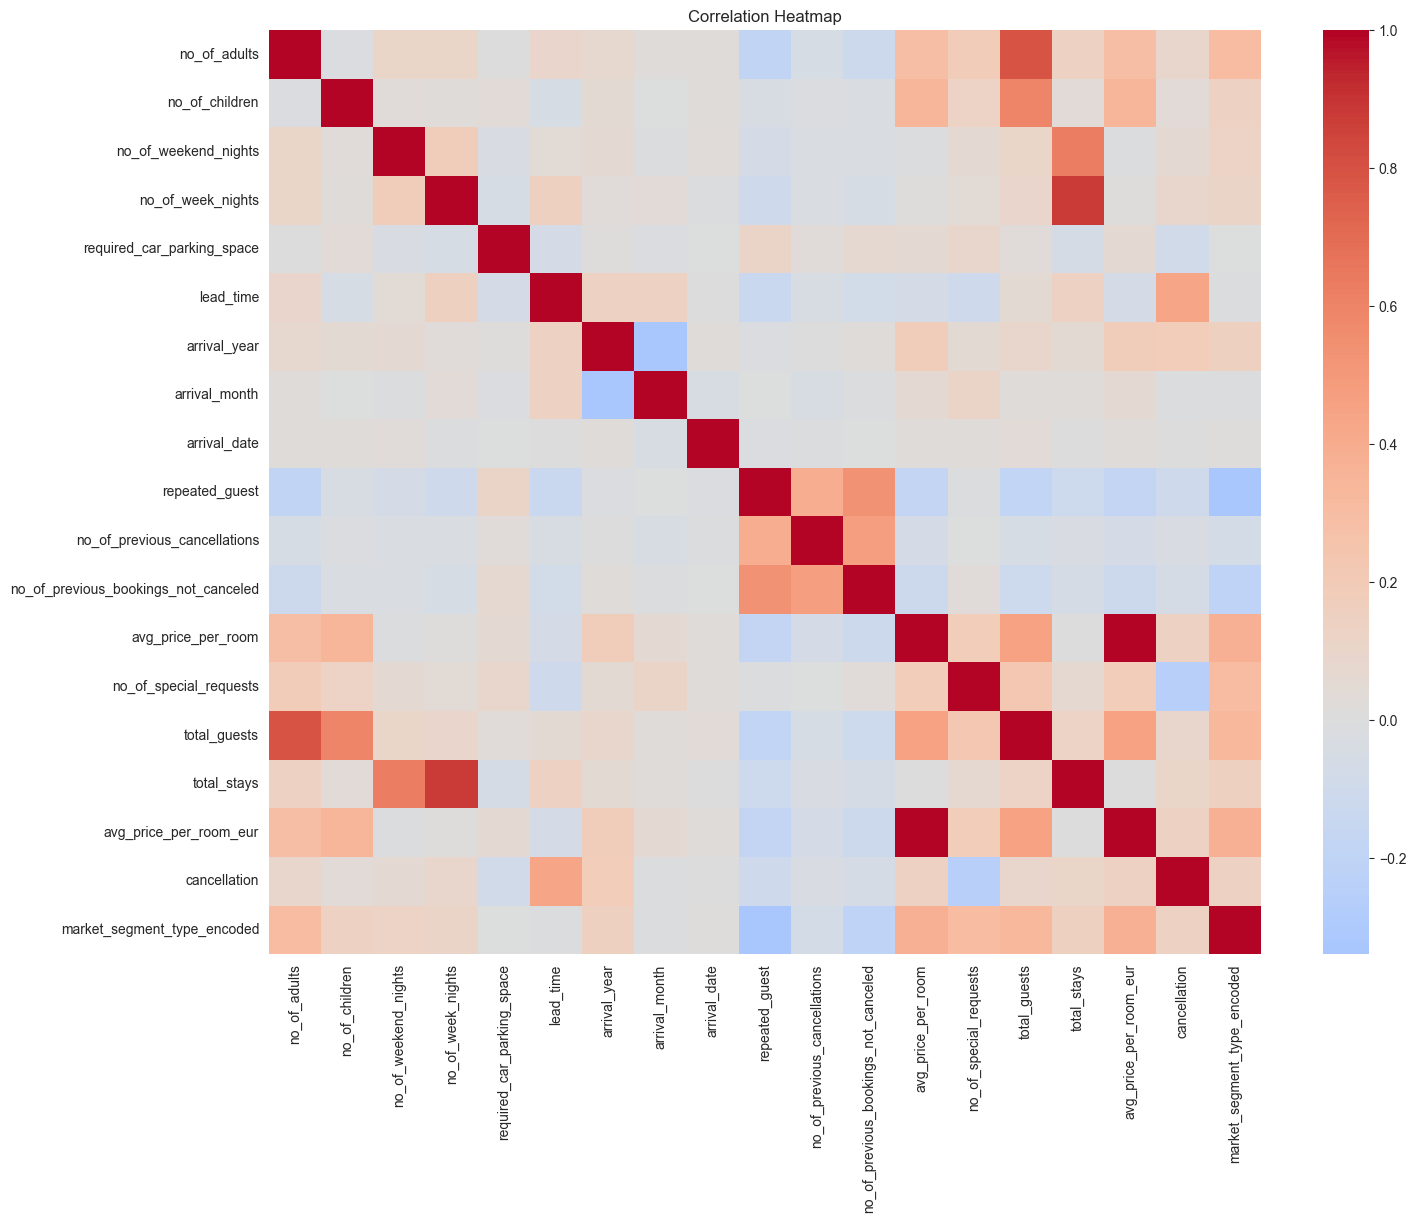

Top correlations with cancellation:
lead_time                               0.438389
no_of_special_requests                 -0.253227
arrival_year                            0.179650
avg_price_per_room                      0.139900
avg_price_per_room_eur                  0.139900
market_segment_type_encoded             0.136248
repeated_guest                         -0.107317
total_stays                             0.101416
no_of_week_nights                       0.091033
total_guests                            0.090149
required_car_parking_space             -0.086489
no_of_adults                            0.086381
no_of_weekend_nights                    0.060323
no_of_previous_bookings_not_canceled   -0.060237
no_of_children                          0.033876
Name: cancellation, dtype: float64


In [192]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
correlation = data[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

target_corr = (
    correlation["cancellation"]
    .drop("cancellation")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top correlations with cancellation:")
print(target_corr.head(15))


## 10) Feature Selection for Model


In [193]:
# Selected to align with app prediction input
selected_features = [
    "lead_time",
    "no_of_special_requests",
    "avg_price_per_room",
    "market_segment_type_encoded",
    "repeated_guest",
    "total_stays",
    "no_of_week_nights",
    "total_guests",
    "required_car_parking_space",
    "no_of_weekend_nights",
    "no_of_previous_bookings_not_canceled",
]

X = data[selected_features].copy()
y = data["cancellation"].copy()

print("Selected features:")
print(selected_features)
print("X shape:", X.shape)


Selected features:
['lead_time', 'no_of_special_requests', 'avg_price_per_room', 'market_segment_type_encoded', 'repeated_guest', 'total_stays', 'no_of_week_nights', 'total_guests', 'required_car_parking_space', 'no_of_weekend_nights', 'no_of_previous_bookings_not_canceled']
X shape: (36194, 11)


## 11) Train-Test Split


In [194]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (28955, 11)
X_test: (7239, 11)


## 12) Train Baseline Random Forest


Confusion Matrix
[[4476  387]
 [ 461 1915]]

Accuracy: 0.8829
ROC-AUC: 0.9436

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4863
           1       0.83      0.81      0.82      2376

    accuracy                           0.88      7239
   macro avg       0.87      0.86      0.87      7239
weighted avg       0.88      0.88      0.88      7239



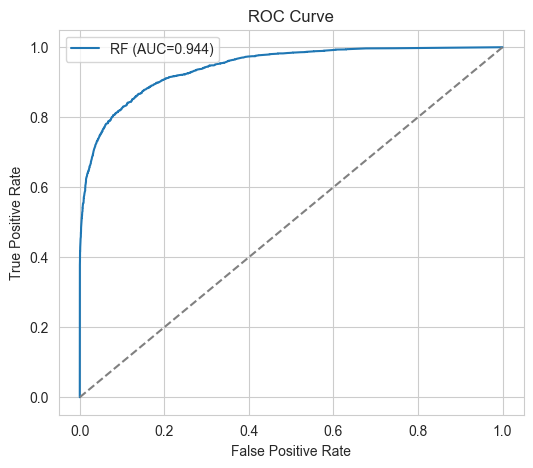

In [195]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, y_prob)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", round(baseline_acc, 4))
print("ROC-AUC:", round(baseline_auc, 4))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"RF (AUC={baseline_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 13) Feature Importance


In [196]:
importance_df = pd.DataFrame(
    {
        "feature": selected_features,
        "importance": rf.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

importance_df


,feature,importance
0,lead_time,0.411037
2,avg_price_per_room,0.251331
1,no_of_special_requests,0.113729
3,market_segment_type_encoded,0.069980
5,total_stays,0.040929
6,no_of_week_nights,0.035848
7,total_guests,0.033139
9,no_of_weekend_nights,0.027977
8,required_car_parking_space,0.009200
4,repeated_guest,0.004384


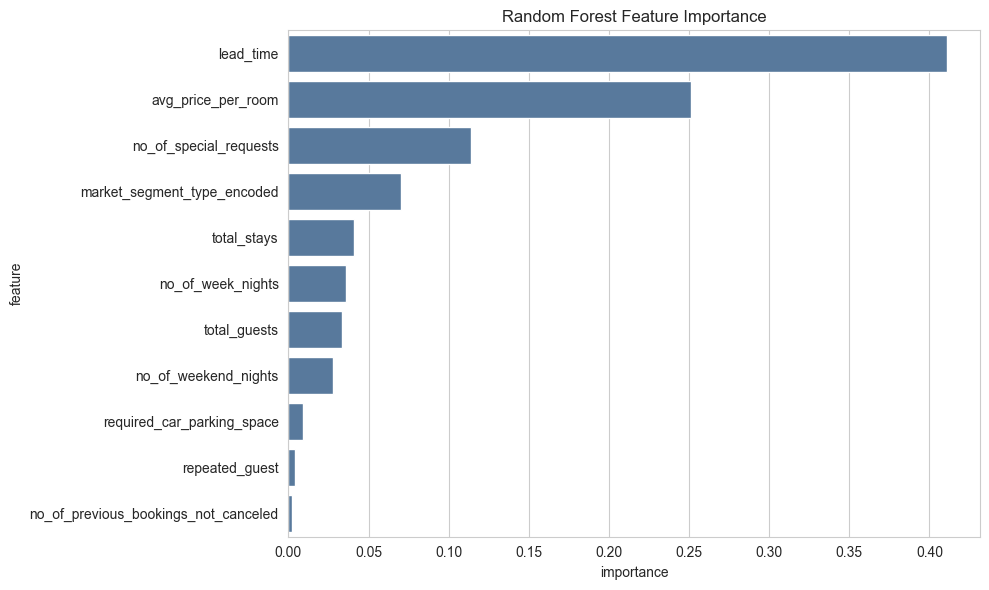

In [197]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#4C78A8")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 16) Save Model Files for Flask App


In [198]:
os.makedirs("model_files", exist_ok=True)

with open("model_files/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("model_files/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open("model_files/feature_cols.pkl", "wb") as f:
    pickle.dump(selected_features, f)

importance_df.to_csv("model_files/feature_importance_full.csv", index=False)
pd.DataFrame({"feature": selected_features}).to_csv("model_files/selected_features.csv", index=False)

print("Saved:")
print("- model_files/random_forest_model.pkl")
print("- model_files/encoders.pkl")
print("- model_files/feature_cols.pkl")
print("- model_files/feature_importance_full.csv")
print("- model_files/selected_features.csv")


Saved:
- model_files/random_forest_model.pkl
- model_files/encoders.pkl
- model_files/feature_cols.pkl
- model_files/feature_importance_full.csv
- model_files/selected_features.csv


## 17) Final Summary


In [199]:
summary = {
    "rows_used": len(data),
    "features_used": selected_features,
    "baseline_accuracy": round(float(baseline_acc), 4),
    "baseline_roc_auc": round(float(baseline_auc), 4),
}

summary


{'rows_used': 36194,
 'features_used': ['lead_time',
  'no_of_special_requests',
  'avg_price_per_room',
  'market_segment_type_encoded',
  'repeated_guest',
  'total_stays',
  'no_of_week_nights',
  'total_guests',
  'required_car_parking_space',
  'no_of_weekend_nights',
  'no_of_previous_bookings_not_canceled'],
 'baseline_accuracy': 0.8829,
 'baseline_roc_auc': 0.9436}